Accuracy: 1.0

Confusion Matrix:
[[2 0]
 [0 1]]


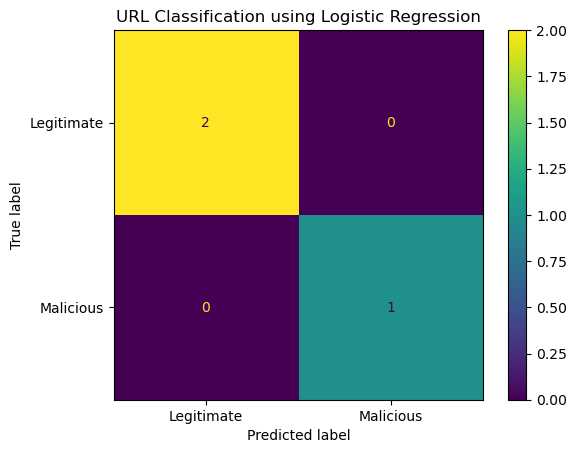

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# URL dataset
urls = [
    "https://google.com", "https://amazon.com",
    "https://github.com", "https://apple.com",
    "https://microsoft.com",
    "http://192.168.1.10/login",
    "http://secure-login.com/verify",
    "http://free-prize.com/winner",
    "http://bank-security.com/login",
    "http://account-verify.com/update"
]

# 0 = Legitimate, 1 = Malicious
labels = [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]

# Extract URL features
def extract_features(url):
    return [
        len(url),
        url.count('.'),
        url.count('-'),
        url.count('/'),
        int(url.startswith("https://")),
        int(bool(re.search(r'(\d{1,3}\.){3}\d{1,3}', url))),
        int(any(word in url.lower()
                for word in ["login", "verify", "bank", "prize", "update"]))
    ]

features = [extract_features(url) for url in urls]

X = pd.DataFrame(features, columns=[
    "Length", "Dots", "Hyphens", "Slashes",
    "HTTPS", "Has_IP", "Suspicious_Word"
])

y = pd.Series(labels)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Legitimate", "Malicious"]
)

plt.title("URL Classification using Logistic Regression")
plt.show()